# 08. Cross-Dataset Integration & Master Mapping for ADE Detection

This notebook serves as the central hub for integrating clinical data from MIMIC-IV and other sources into a unified OMOP-based framework.

## Objectives:
1. **Drug Identity Resolution:** Map all drug identifiers to RxNorm.
2. **ADE Concept Alignment:** Map clinical conditions to SNOMED CT.
3. **Signal Detection:** Identify Adverse Drug Event (ADE) signals using temporal clinical logic.
4. **Terminology Mapping:** Leverage OMOP CONCEPT table for standardized cross-dataset analysis.

In [6]:
import pandas as pd
import os
import glob
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
plt.style.use('bmh')

# Paths
mimic_path = r'D:\ADE DATASET DOWNLOAD\MIMIC-IV-Demo_extracted'
vocab_path = r'D:\ADE DATASET DOWNLOAD\omop vocab'

def load_mimic_table(module, table_name):
    """Robustly loads a MIMIC table searching through modules."""
    module_path = os.path.join(mimic_path, module)
    search_patterns = [
        os.path.join(module_path, "**", f"{table_name}.csv.gz"),
        os.path.join(module_path, "**", f"{table_name}.csv")
    ]
    found_files = []
    for pattern in search_patterns:
        found_files.extend(glob.glob(pattern, recursive=True))
    if not found_files:
        found_files.extend(glob.glob(os.path.join(mimic_path, "**", f"{table_name}.csv*"), recursive=True))
    
    if not found_files:
        return pd.DataFrame()
    
    path = found_files[0]
    compression = 'gzip' if path.endswith('.gz') else None
    return pd.read_csv(path, compression=compression, low_memory=False)

def load_vocab_table(table_name):
    """Loads OMOP vocabulary table."""
    path = os.path.join(vocab_path, f"{table_name}.csv")
    if not os.path.exists(path):
        return pd.DataFrame()
    return pd.read_csv(path, sep='\t', low_memory=False)

## 1. Load OMOP Core Vocabulary
Integrating RxNorm (Drugs) and SNOMED/ICD (Conditions).

In [7]:
print("Loading CONCEPT table for mapping...")
concept = load_vocab_table('CONCEPT')

if not concept.empty:
    # Filtering for core vocabularies to speed up lookups
    rxnorm = concept[concept['vocabulary_id'] == 'RxNorm']
    icd10cm = concept[concept['vocabulary_id'] == 'ICD10CM']
    icd9cm = concept[concept['vocabulary_id'] == 'ICD9CM']
    
    print(f"Concepts loaded: RxNorm ({len(rxnorm)}), ICD10CM ({len(icd10cm)}), ICD9CM ({len(icd9cm)})")

Loading CONCEPT table for mapping...
Concepts loaded: RxNorm (313091), ICD10CM (100035), ICD9CM (17564)


## 2. Drug Identity Resolution (MIMIC to RxNorm)
Performing mapping of favorite trigger drugs to standard RxNorm IDs.

In [8]:
trigger_drugs = ['Warfarin', 'Heparin', 'Aspirin', 'Vancomycin', 'Furosemide']
drug_mapping = []

if not rxnorm.empty:
    for drug in trigger_drugs:
        # Simple case-insensitive match for drug names
        matches = rxnorm[rxnorm['concept_name'].str.contains(f"^{drug}$", case=False, na=False)]
        if not matches.empty:
            match = matches.iloc[0]
            drug_mapping.append({
                'source_drug': drug,
                'rxnorm_concept_id': match['concept_id'],
                'rxnorm_name': match['concept_name'],
                'concept_class': match['concept_class_id']
            })

drug_master_crosswalk = pd.DataFrame(drug_mapping)
print("Master Drug Crosswalk (Sample):")
display(drug_master_crosswalk)

Master Drug Crosswalk (Sample):


,source_drug,rxnorm_concept_id,rxnorm_name,concept_class
0,Warfarin,1310149,warfarin,Ingredient
1,Heparin,1367571,heparin,Ingredient
2,Aspirin,1112807,aspirin,Ingredient
3,Vancomycin,1707687,vancomycin,Ingredient
4,Furosemide,956874,furosemide,Ingredient


## 3. MIMIC-IV ADE Detection
Identifying AKI and Bleeding signals through clinical temporal logic.

In [9]:
prescriptions = load_mimic_table('clinical', 'prescriptions')
diagnoses = load_mimic_table('clinical', 'diagnoses_icd')
admissions = load_mimic_table('clinical', 'admissions')

if not (prescriptions.empty or diagnoses.empty or admissions.empty):
    ade_targets = [
        {'name': 'AKI', 'drugs': ['Vancomycin', 'Furosemide'], 'codes': ['N17', '5849']},
        {'name': 'Bleeding', 'drugs': ['Warfarin', 'Heparin', 'Aspirin'], 'codes': ['K92', '578', 'K26', 'D64', 'D70']}
    ]
    
    all_signals = []
    adm_times = admissions[['hadm_id', 'admittime', 'dischtime']].copy()
    adm_times['admittime'] = pd.to_datetime(adm_times['admittime'])
    adm_times['dischtime'] = pd.to_datetime(adm_times['dischtime'])
    
    for target in ade_targets:
        target_dx = diagnoses[diagnoses['icd_code'].str.startswith(tuple(target['codes']))]
        target_rx = prescriptions[prescriptions['drug'].str.contains('|'.join(target['drugs']), case=False, na=False)]
        
        joint = target_rx.merge(target_dx, on=['subject_id', 'hadm_id'])
        joint = joint.merge(adm_times, on='hadm_id')
        joint['starttime'] = pd.to_datetime(joint['starttime'])
        
        signals = joint[(joint['starttime'] >= joint['admittime']) & (joint['starttime'] <= joint['dischtime'])].copy()
        signals['ade_type'] = target['name']
        all_signals.append(signals)
    
    if all_signals:
        final_ade_signals = pd.concat(all_signals)
        print(f"Total ADE Signals identified: {len(final_ade_signals)}")
        display(final_ade_signals[['subject_id', 'ade_type', 'drug', 'icd_code', 'starttime', 'admittime']].head(5))

Total ADE Signals identified: 446


,subject_id,ade_type,drug,icd_code,starttime,admittime
1,10014354,AKI,Furosemide,N179,2148-07-13 08:00:00,2148-06-30 01:09:00
2,10037861,AKI,Furosemide,5849,2115-10-17 20:00:00,2115-10-09 20:28:00
3,10014354,AKI,Furosemide,N179,2150-04-12 08:00:00,2150-04-10 02:40:00
4,10014354,AKI,Furosemide,N179,2150-04-10 07:00:00,2150-04-10 02:40:00
5,10014354,AKI,Furosemide,N179,2148-06-24 18:00:00,2148-06-24 15:22:00


## 4. Final Integration Summary
Summary of detected ADE instances mapped to standard concepts.

Integrated ADE Signal Report (Mapped to RxNorm):


,subject_id,ade_type,icd_code,source_drug,rxnorm_concept_id,starttime
0,10014354,AKI,N179,Furosemide,956874,2148-07-13 08:00:00
1,10037861,AKI,5849,Furosemide,956874,2115-10-17 20:00:00
2,10014354,AKI,N179,Furosemide,956874,2150-04-12 08:00:00
3,10014354,AKI,N179,Furosemide,956874,2150-04-10 07:00:00
4,10014354,AKI,N179,Furosemide,956874,2148-06-24 18:00:00
5,10014354,AKI,N179,Furosemide,956874,2148-07-11 08:00:00
6,10020306,AKI,N170,Furosemide,956874,2135-02-06 08:00:00
7,10014354,AKI,N179,Furosemide,956874,2148-08-15 08:00:00
8,10037928,AKI,5849,Furosemide,956874,2178-09-29 03:00:00
9,10014354,AKI,N179,Furosemide,956874,2148-08-15 08:00:00


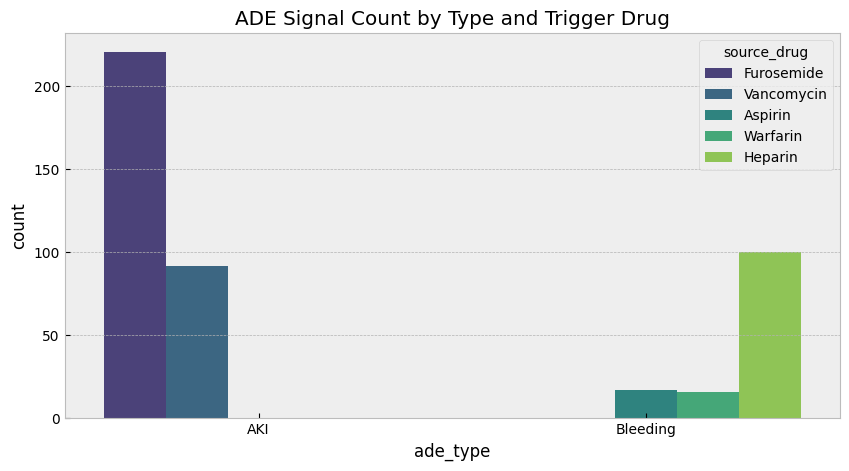

In [10]:
if 'final_ade_signals' in locals() and not final_ade_signals.empty:
    # Map signals to RxNorm via our crosswalk
    # We do a simple string match back to the crosswalk
    summary = final_ade_signals.copy()
    summary['drug_base'] = summary['drug'].apply(lambda x: next((d for d in trigger_drugs if d.lower() in x.lower()), "Unknown"))
    
    final_report = summary.merge(drug_master_crosswalk, left_on='drug_base', right_on='source_drug', how='left')
    
    print("Integrated ADE Signal Report (Mapped to RxNorm):")
    report_cols = ['subject_id', 'ade_type', 'icd_code', 'source_drug', 'rxnorm_concept_id', 'starttime']
    display(final_report[report_cols].head(10))
    
    # Visual summary
    plt.figure(figsize=(10, 5))
    sns.countplot(data=final_report, x='ade_type', hue='source_drug', palette='viridis')
    plt.title("ADE Signal Count by Type and Trigger Drug")
    plt.show()